In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

In [2]:
%%capture
ds = ekd.from_source(
    "ads",
    "cams-global-atmospheric-composition-forecasts",
    request = {
    "date": ["2026-07-25/2026-07-30"],
    "time": ["00:00"],
    "leadtime_hour": list(range(0, 121, 3)),
    "type": ["forecast"],
    "data_format": "grib",
    "variable": ["total_aerosol_optical_depth_550nm"],
    "area": [90, -180, -60, 180]
}
).to_xarray()

In [3]:
ds

<xarray.Dataset> Size: 666MB
Dimensions:                  (forecast_reference_time: 6, step: 41,
                              latitude: 376, longitude: 900)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[us] 48B 202...
  * step                     (step) timedelta64[us] 328B 00:00:00 ... 5 days ...
  * latitude                 (latitude) float64 3kB 90.0 89.6 ... -59.6 -60.0
  * longitude                (longitude) float64 7kB -180.0 -179.6 ... 179.6
Data variables:
    aod550                   (forecast_reference_time, step, latitude, longitude) float64 666MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

In [4]:
# Select forecast 
aod = ds["aod550"].sel(
    forecast_reference_time="2026-07-25"
)

In [5]:
# Convert longitude from 0–360 to -180–180
aod = (
    aod.assign_coords(
        longitude=((aod.longitude + 180) % 360) - 180
    )
    .sortby("longitude")
)

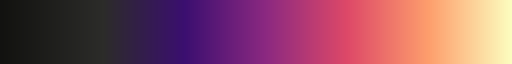

In [6]:
# Custom color map
colors = [
    (0.00, "#121210"),
    (0.20, "#2c2c29"),    
    (0.36, "#3b0f70"),
    (0.52, "#8c2981"),
    (0.68, "#de4968"),
    (0.84, "#fe9f6d"),
    (1.00, "#fcfdbf"),
]

cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    colors,
    N=256
)
cmap

In [ ]:
# Figure and projection
fig, ax = plt.subplots(
    figsize=(10, 7),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

# Background colours
fig.set_facecolor("#121210")
ax.set_facecolor("#121210")

# Caption
fig.text(0.5, 0.2, "CAMS global atmospheric composition forecasts | DOI: 10.24381/04a0b097 | Created by: Bernadett Piros", color="grey", size=8, ha="center")

# Base map
ax.add_feature(
    cfeature.OCEAN,
    facecolor="#121210",   
    zorder=0,
)

ax.add_feature(
    cfeature.LAND,
    facecolor="#2c2c29",   
    zorder=1,
)

# First frame
data = aod.isel(step=0).compute()

mesh = ax.pcolormesh(
    data.longitude,
    data.latitude,
    data.values,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    shading="auto",
    vmin=0,
    vmax=2,
    zorder=2,
)


# Map features
ax.coastlines(
    color="grey",
    linewidth=0.4,   
    zorder=3,
)

ax.add_feature(
    cfeature.BORDERS,
    edgecolor="grey",
    linewidth=0.4,   
    zorder=3,
)

title = ax.set_title(
    "",
    color="lightgrey",
    fontsize=16,
    pad=12,
)

# Bold title
title.set_fontweight("bold")

# Remove axis
ax.axis("off")

# Function to update the current animation frame
def update(i):

    data = aod.isel(step=i).compute()

    mesh.set_array(data.values.ravel())

    if "valid_time" in ds:
        valid = (
            ds["valid_time"]
            .sel(forecast_reference_time="2026-07-25")
            .isel(step=i)
            .values
        )
    else:
        valid = (
            aod.forecast_reference_time.values
            + aod.step.isel(step=i).values
        )

    valid = pd.to_datetime(valid).strftime("%Y-%m-%d  %H:%M UTC")

    title.set_text(
        f"CAMS Total Aerosol Optical Depth 550 nm\n{valid}"
    )

    return mesh, title


# Animation
ani = animation.FuncAnimation(
    fig,
    update,
    frames=aod.sizes["step"],
    interval=300,
    blit=False,
)

# Save
ani.save(
    "aod.gif",
    writer="pillow",
    fps=2,
)